# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

import comet_ml
import json

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay, f1_score, precision_score
from sklearn.calibration import CalibrationDisplay
from sklearn.linear_model import LogisticRegression

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.selection_scripts import create_best_selection_path, find_optimal_cut_point
from analysis_scripts.estimate_scripts import signal_estimates
from analysis_scripts.draw_scripts import draw_feature_distribution, draw_roc

CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Load preprocessed data

In [2]:
train_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_train_2.csv').drop('Unnamed: 0', axis=1)
test_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_test_1.csv').drop('Unnamed: 0', axis=1)

assert not train_df.isna().sum().sum(), 'Train, data containes NaNs!!'
assert not test_df.isna().sum().sum(), 'Test, data containes NaNs!!'

# Prepare Data

Exclude variables that affect background shape: 
* is_mass_window,
* mass_Lc,
* mass_pt_correlation
* ?Mt_Lc?

In [3]:
# Comet logger
# experiment = comet_ml.Experiment(
#     project_name="SPD ML",
#     workspace="artem-smirnov",
#     api_key="yyKk8vacVuy8dbttSCIgF2iQO"
# )

x = train_df.drop(['tag'], axis=1).copy()
y = train_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()

x_train_full, x_val_full, y_train, y_val = train_test_split(x, y, test_size=0.2, shuffle=True, stratify=y, random_state=CFG.seed)

features_list = CFG.feature_set_3

x_train = x_train_full[features_list].copy()
x_val = x_val_full[features_list].copy()

x_test_full = test_df.drop(['tag'], axis=1).copy()

x_test = test_df[features_list].copy()
y_test = test_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()


try:
    experiment.set_name('feature_set_1, params_xgboost_1')
    formatted_text = json.dumps({"feature_names": features_list}, indent=2)
    experiment.log_text(text=formatted_text)
except NameError:
    pass

In [4]:
# Feature encoding
if features_list == CFG.feature_set_1:
    cols_to_encode = [
        'highest_pt_daughter', 'highest_momentum_daughter', 'highest_OA_daughter',
        'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
    ]
elif features_list == CFG.feature_set_2:
    cols_to_encode = [
    ]
elif features_list == CFG.feature_set_3:
    cols_to_encode = ['highest_momentum_daughter']

preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(sparse_output=False, dtype=int), cols_to_encode)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

preprocessor.fit(x_train)
x_train_encoded = preprocessor.transform(x_train)
x_val_encoded = preprocessor.transform(x_val)
x_test_encoded = preprocessor.transform(x_test)

feature_names = preprocessor.get_feature_names_out()

x_train = pd.DataFrame(x_train_encoded, columns=feature_names, index=x_train.index)
x_val = pd.DataFrame(x_val_encoded, columns=feature_names, index=x_val.index)
x_test = pd.DataFrame(x_test_encoded, columns=feature_names, index=x_test.index)


# Drop excluded columns
if features_list == CFG.feature_set_2:
    
    pass
    
elif features_list == CFG.feature_set_3:
    
    features_to_drop = [
        'highest_momentum_daughter_P_pip', 'highest_momentum_daughter_P_p',
    ]
    
    x_train = x_train.drop(columns=features_to_drop)
    x_val = x_val.drop(columns=features_to_drop)
    x_test = x_test.drop(columns=features_to_drop)

In [5]:
for feature in features_list:
    
    if feature in CFG.cols_to_log_transform:
        pass
        # x_train[feature + '_log'] = np.log1p(x_train[feature])
        # x_val[feature + '_log'] = np.log1p(x_val[feature])
        # x_test[feature + '_log'] = np.log1p(x_test[feature])
    
    if feature in CFG.continual_features:
        pass
        # x_train[feature + '_pct'] = x_train[feature].rank(pct=True)
        # x_val[feature + '_pct'] = x_val[feature].rank(pct=True)
        # x_test[feature + '_pct'] = x_test[feature].rank(pct=True)
        
        # x_train[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_val[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_test[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)

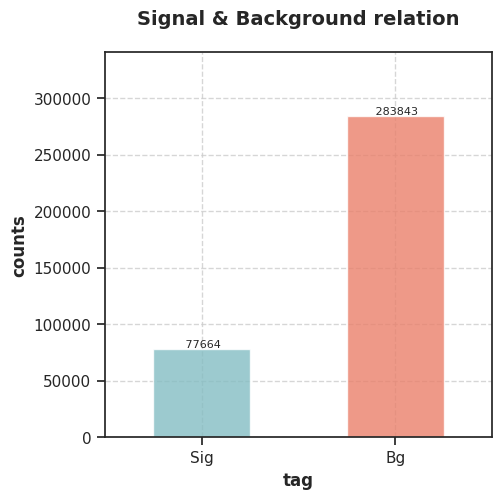

<Figure size 640x480 with 0 Axes>

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

temp_df = pd.concat([x_train, y_train], axis=1)
temp_df['tag'] = temp_df['tag'].map({1: 'Sig', 0: 'Bg'})

sns.countplot(
    data = temp_df,
    x='tag',
    hue='tag',
    width=0.5,
    alpha=0.8,
    order=['Sig', 'Bg'],
    palette={'Sig': '#7AC5CD', 'Bg': '#FF7256'},
    ax=ax
)

max_value = temp_df['tag'].value_counts().max()
ax.set_ylim(0, max_value * 1.2)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + height * 0.001,
                f'{height: .0f}', ha='center', va='bottom', fontsize=8)

ax.set_title("Signal & Background relation", fontsize=14, fontweight='bold', pad=20)

ax.set_xlabel("tag", fontweight='bold')
ax.set_ylabel("counts", fontweight='bold')

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

ax.grid(True, alpha=0.8, linestyle='--')

plt.show()
plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/sig_bg_relation_train.pdf')

In [7]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train = pd.DataFrame(scaler.transform(x_train), columns=x_train.columns, index=x_train.index)
x_val = pd.DataFrame(scaler.transform(x_val), columns=x_val.columns, index=x_val.index)
x_test = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)

# sklearn LogisticRegression

### Feature Importance

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_77443/1843880744.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


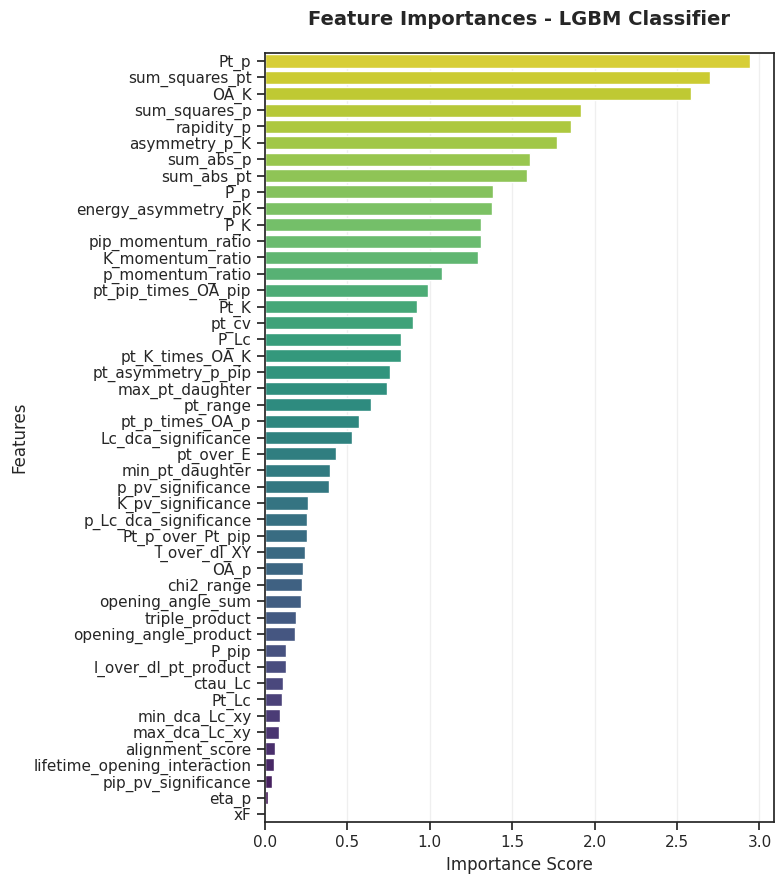

In [10]:
params={}
params.update({
    'penalty': 'l2',
    'solver': 'lbfgs',
    'fit_intercept': True,
    'verbose': 0,
    'n_jobs': 6,
    'random_state': CFG.seed
})

model = LogisticRegression(**params)
model.fit(x_train, y_train)

feature_names = x_train.columns
importance_scores = np.abs(model.coef_).flatten()

feature_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_scores
}).sort_values('importance', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 9))

sns.barplot(
    data=feature_df,
    x='importance',
    y='feature',
    palette='viridis_r',
    orient='h'
)

plt.title(f'Feature Importances - LGBM Classifier', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
# plt.savefig('test.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)
plt.show()

### RFE

In [ ]:
from sklearn.feature_selection import RFECV


params={}
params.update({
    'penalty': 'l2',
    'solver': 'lbfgs',
    'fit_intercept': True,
    'verbose': 0,
    'n_jobs': 6,
    'random_state': CFG.seed
})

estimator = LogisticRegression(**params)

selector = RFECV(
    estimator, 
    step=1, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=6,
    verbose=1,
)

selector = selector.fit(x_train, y_train)

mean_scores = selector.cv_results_['mean_test_score']
std_scores = selector.cv_results_['std_test_score']

optimal_score = np.max(mean_scores)
optimal_idx = np.argmax(mean_scores)

print("Optimal number of features:", selector.n_features_)
print(f"Best score: {optimal_score:.4f}")
print("Selected features:")
for feat in x_train.columns[selector.support_]:
    print(f"  - {feat}")

# Plot RFE
plt.figure(figsize=(14, 8))

n_features_range = range(selector.min_features_to_select, 
                        len(mean_scores) + selector.min_features_to_select)

df_scores = pd.DataFrame({
    'Number of Features': n_features_range,
    'Mean Score': mean_scores,
    'Std Score': std_scores
})

confidence_multiplier = 1.96
df_scores['Upper_CI'] = df_scores['Mean Score'] + confidence_multiplier * df_scores['Std Score']
df_scores['Lower_CI'] = df_scores['Mean Score'] - confidence_multiplier * df_scores['Std Score']


plt.fill_between(df_scores['Number of Features'], 
                df_scores['Lower_CI'], 
                df_scores['Upper_CI'], 
                alpha=0.3, 
                color='steelblue',
                label='95% Confidence Interval')

line_plot = sns.lineplot(data=df_scores, 
                        x='Number of Features', 
                        y='Mean Score',
                        marker='o',
                        linewidth=2.5,
                        markersize=8,
                        color='steelblue',
                        label='Mean Score')

optimal_features = selector.n_features_
plt.axvline(x=optimal_features, color='red', linestyle='--', alpha=0.7, 
            linewidth=2, label=f'Optimal: {optimal_features} features')

optimal_point = plt.scatter(optimal_features, optimal_score, 
                        color='red', s=200, zorder=5, 
                        label=f'Optimal Score: {optimal_score:.4f}',
                        edgecolors='black', linewidth=2)


plt.title('RFECV Performance: Score vs Number of Features\n(with 95% Confidence Intervals)', 
        fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Features', fontsize=12, fontweight='bold')
plt.ylabel('Mean ROC-AUC Score', fontsize=12, fontweight='bold')
plt.xticks(list(n_features_range))
plt.grid(True, alpha=0.3)
plt.legend(loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*60)
print("Results (Mean +- 1.96*Std for 95% CI):")
print("="*60)

for i, (n_feat, mean_score, std_score) in enumerate(zip(n_features_range, mean_scores, std_scores)):
    ci_lower = mean_score - 1.96 * std_score
    ci_upper = mean_score + 1.96 * std_score
    marker = " ← OPTIMAL" if n_feat == optimal_features else ""
    print(f"Features: {n_feat:2d} | Score: {mean_score:.4f} | "
        f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]{marker}")

print("="*60)

# plt.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/xgboost_RFE.pdf', bbox_inches='tight')

Fitting estimator with 47 features.
Fitting estimator with 47 features.
Fitting estimator with 47 features.
Fitting estimator with 47 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 46 features.
Fitting estimator with 46 features.
Fitting estimator with 46 features.


/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 45 features.
Fitting estimator with 45 features.
Fitting estimator with 45 features.


/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 44 features.
Fitting estimator with 44 features.
Fitting estimator with 44 features.


...

Fitting estimator with 43 features.


/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 42 features.
Fitting estimator with 42 features.
Fitting estimator with 42 features.
Fitting estimator with 42 features.


/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 42 features.
Fitting estimator with 41 features.


### Cross-validation

In [9]:
params={}
params.update({
    'penalty': 'l2',
    'solver': 'liblinear',
    'fit_intercept': True,
    'verbose': 0,
    'n_jobs': 6,
    'random_state': CFG.seed
})

try:
    experiment.log_parameters(params)
except NameError:
    pass

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)
split_generator = skf.split(x_train, y_train)

train_scores = []
val_scores = []
for fold, (train_idx, val_idx) in enumerate(split_generator):
    
    fold_x_train = x_train.iloc[train_idx, :]
    fold_y_train = y_train.iloc[train_idx]
    fold_x_val = x_train.iloc[val_idx, :]
    fold_y_val = y_train.iloc[val_idx]
    
    fold_model = LogisticRegression(**params)
    
    fold_model.fit(fold_x_train, fold_y_train)
    
    fold_train_pred_proba = fold_model.predict_proba(fold_x_train)[:, 1]
    fold_val_pred_proba = fold_model.predict_proba(fold_x_val)[:, 1]
    
    fold_train_score = roc_auc_score(fold_y_train, fold_train_pred_proba)
    fold_val_score = roc_auc_score(fold_y_val, fold_val_pred_proba)
    
    train_scores.append(fold_train_score)
    val_scores.append(fold_val_score)

    print(f'\nFold {fold} result:  train score: {fold_train_score:0.3f}, val score: {fold_val_score: 0.3f}\n')


train_scores = np.array(train_scores)
val_scores = np.array(val_scores)

try:
    experiment.log_metrics({
        'cv_train_mean_roc_auc':  train_scores.mean(),
        'cv_val_mean_roc_auc':  val_scores.mean()
    })
except NameError:
    pass

print(f'\n\nMean CV train score: {train_scores.mean():0.3f}')
print(f'Mean CV val score: {val_scores.mean():0.3f}')

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(



Fold 0 result:  train score: 0.964, val score:  0.964



/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(



Fold 1 result:  train score: 0.964, val score:  0.965



/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(



Fold 2 result:  train score: 0.964, val score:  0.964



/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(



Fold 3 result:  train score: 0.964, val score:  0.963



/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(



Fold 4 result:  train score: 0.964, val score:  0.963



Mean CV train score: 0.964
Mean CV val score: 0.964


### Single Model Estimation

#### Create model

In [9]:
params={}
params.update({
    'penalty': 'l2',
    'solver': 'lbfgs',
    'fit_intercept': True,
    'verbose': 0,
    'n_jobs': 6,
    'random_state': CFG.seed
})

model = LogisticRegression(**params)
model.fit(x_train, y_train)

# Evaluate on train set
y_pred_train = model.predict(x_train)
y_pred_proba_train = model.predict_proba(x_train)[:, 1]

print(f'\n{'#'*60}')
print(f"Train set performance:\n")
print(classification_report(y_true=y_train, y_pred=y_pred_train))
print(f"ROC-AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_train, y_pred_proba_train))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_train, y_pred_proba_train))
except NameError:
    pass

# Evaluate on val set
y_pred_val = model.predict(x_val)
y_pred_proba_val = model.predict_proba(x_val)[:, 1]

print(f'\n{'#'*60}')
print(f"Val set performance:\n")
print(classification_report(y_true=y_val, y_pred=y_pred_val))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_val):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_val, y_pred_proba_val))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_val, y_pred_proba_val))
except NameError:
    pass

# Evaluate on test set
y_pred_test = model.predict(x_test)
y_pred_proba_test = model.predict_proba(x_test)[:, 1]

print(f'\n{'#'*60}')
print(f"Test set performance:\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_test, y_pred_proba_test))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_test, y_pred_proba_test))
except NameError:
    pass

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



############################################################
Train set performance:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95    283843
           1       0.83      0.80      0.82     77664

    accuracy                           0.92    361507
   macro avg       0.89      0.88      0.88    361507
weighted avg       0.92      0.92      0.92    361507

ROC-AUC: 0.9686

############################################################
Val set performance:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95     70961
           1       0.83      0.80      0.82     19416

    accuracy                           0.92     90377
   macro avg       0.89      0.88      0.88     90377
weighted avg       0.92      0.92      0.92     90377

ROC-AUC: 0.9683

############################################################
Test set performance:

              precision    recall  f1-score   support

    

#### Classifier Calibration

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


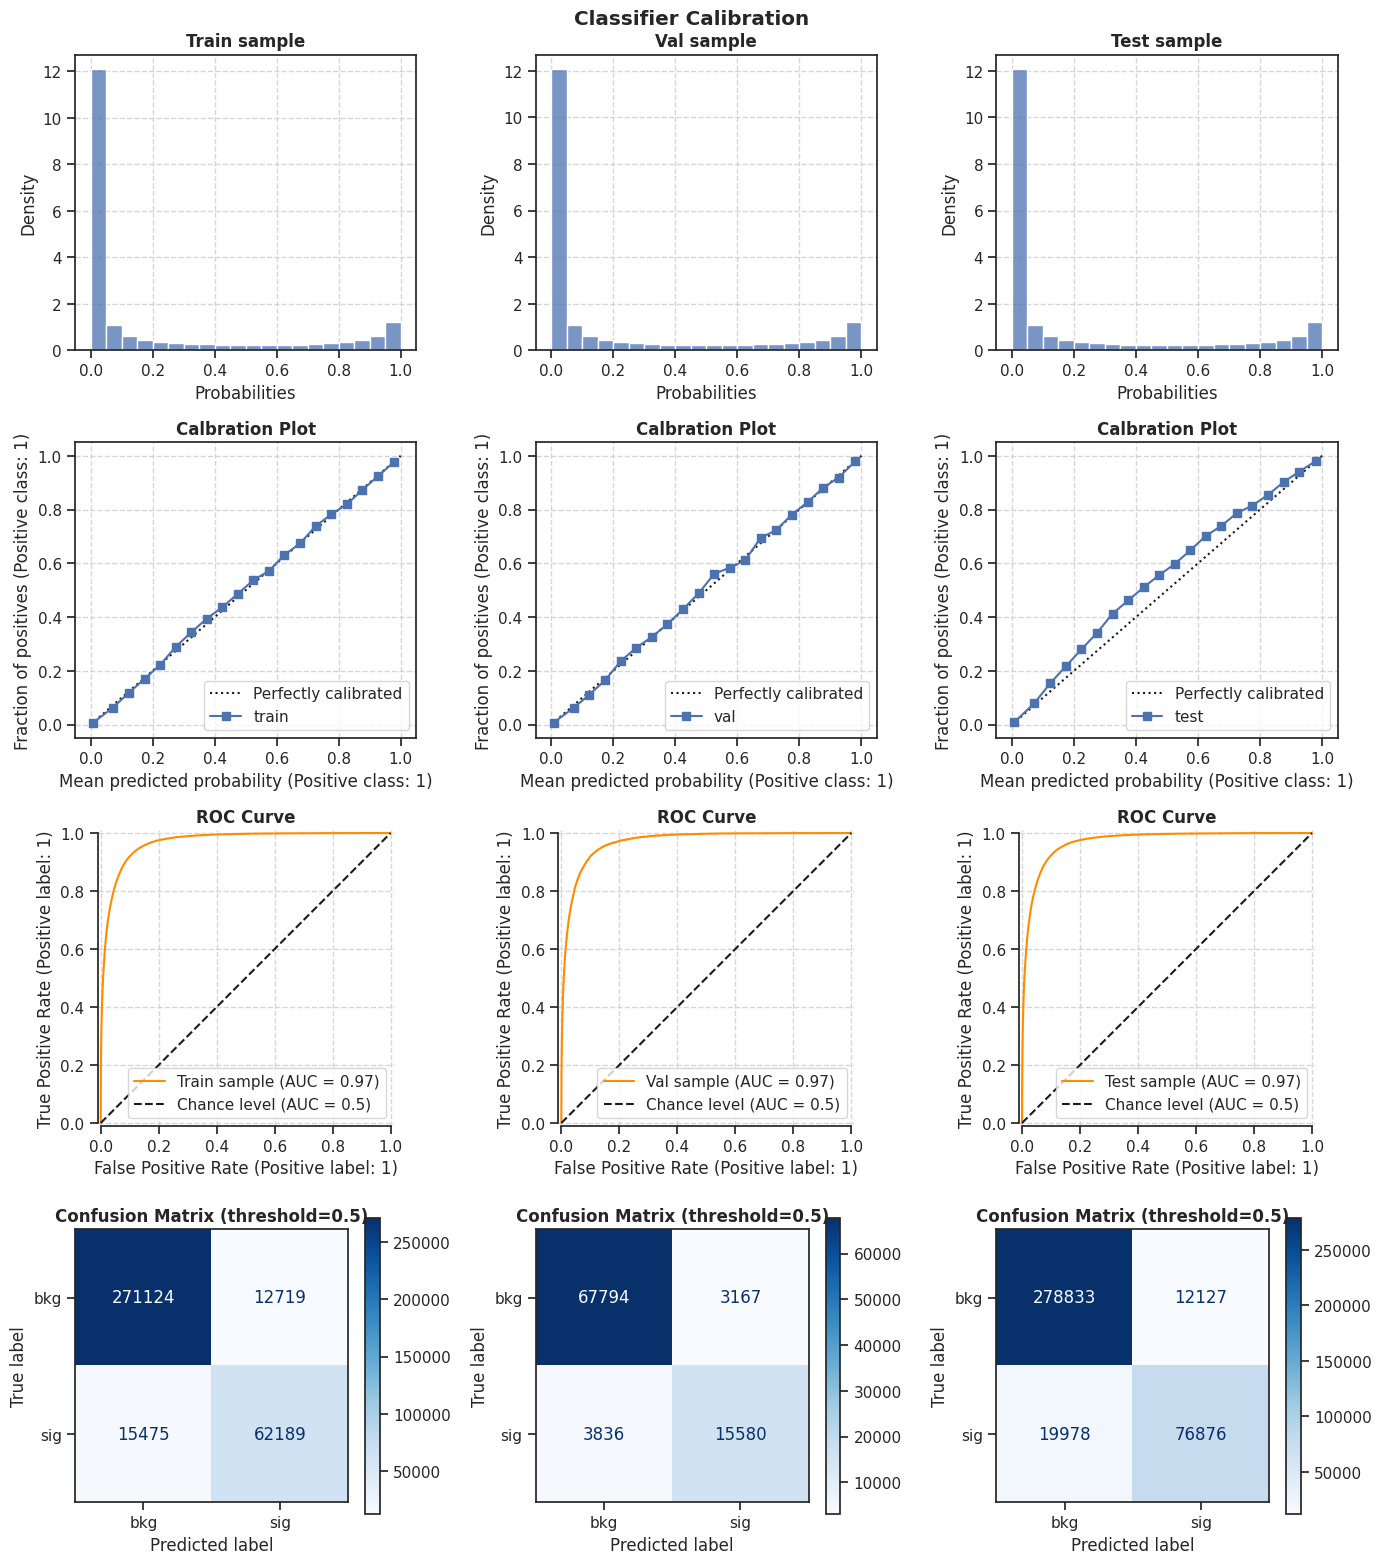

In [10]:
n_bins=20

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 16))
fig.suptitle('Classifier Calibration', fontweight='bold')

#######################################
sns.histplot(
    data=y_pred_proba_train,
    stat='density',
    bins=n_bins,
    ax=axes[0][0]
)

axes[0][0].set_title('Train sample', fontweight='bold')
axes[0][0].set_xlabel('Probabilities')
axes[0][0].set_ylabel('Density')
axes[0][0].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_train, y_pred_proba_train, name='train', n_bins=n_bins, ax=axes[1][0])

axes[1][0].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][0].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_pred_proba_train,
    name=f"Train sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][0]
)

axes[2][0].set_title('ROC Curve', fontweight='bold')
axes[2][0].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_train, 
    y_pred=y_pred_train,
    display_labels=['bkg', 'sig'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][0]
)

axes[3][0].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
sns.histplot(
    data=y_pred_proba_val,
    stat='density',
    bins=n_bins,
    ax=axes[0][1]
)

axes[0][1].set_title('Val sample', fontweight='bold')
axes[0][1].set_xlabel('Probabilities')
axes[0][1].set_ylabel('Density')
axes[0][1].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_val, y_pred_proba_val, name='val', n_bins=n_bins, ax=axes[1][1])

axes[1][1].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][1].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_val,
    y_pred=y_pred_proba_val,
    name=f"Val sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][1]
)

axes[2][1].set_title('ROC Curve', fontweight='bold')
axes[2][1].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_val, 
    y_pred=y_pred_val,
    display_labels=['bkg', 'sig'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][1]
)

axes[3][1].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
sns.histplot(
    data=y_pred_proba_val,
    stat='density',
    bins=n_bins,
    ax=axes[0][2]
)

axes[0][2].set_title('Test sample', fontweight='bold')
axes[0][2].set_xlabel('Probabilities')
axes[0][2].set_ylabel('Density')
axes[0][2].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_test, y_pred_proba_test, name='test', n_bins=n_bins, ax=axes[1][2])

axes[1][2].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][2].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_proba_test,
    name=f"Test sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][2]
)

axes[2][2].set_title('ROC Curve', fontweight='bold')
axes[2][2].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, 
    y_pred=y_pred_test,
    display_labels=['bkg', 'sig'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][2]
)

axes[3][2].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
plt.tight_layout()

try:
    experiment.log_figure(
        figure_name=f"Calibration plots",
        figure=plt.gcf()
    )
except NameError:
    pass

fig.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/calibration_plot.pdf', bbox_inches='tight')
plt.show()

#### Optimize threshold

In [11]:
# From data_explore section
sig_eff_presel = CFG.sig_eff_presel
bg_eff_presel = CFG.bg_eff_presel

pred_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba': y_pred_proba_test
})

thresholds = np.arange(0.1, 1, 0.05)
f1_scores = []
precision_scores = []
s_over_b = []

for threshold in thresholds:
    
    signal_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 1), 'y_true'].count()
    signal_counts_before = pred_df.loc[pred_df.y_true == 1, 'y_true'].count()
    background_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 0), 'y_true'].count()
    background_counts_before = pred_df.loc[pred_df.y_true == 0, 'y_true'].count()

    signal_eff_ML = signal_counts_after / signal_counts_before
    background_eff_ML = background_counts_after / background_counts_before

    total_sig_efficiency = sig_eff_presel * signal_eff_ML
    total_bg_suppression = bg_eff_presel * background_eff_ML

    sig_mass_distr = test_df.loc[test_df['tag'] == 'Sig', 'mass_Lc']
    bg_mass_distr = test_df.loc[test_df['tag'] == 'Bg', 'mass_Lc']

    overall_s_b, *_ = signal_estimates(
        sig_mass_distr=sig_mass_distr,
        bg_mass_distr=bg_mass_distr,
        have_sig_events=CFG.have_sig_events_1 / signal_eff_ML, 
        have_bg_events=CFG.have_bg_events_1 / background_eff_ML,
        mass_interval=CFG.mass_interval, 
        visualization=False,
        verbose=False
    )
    
    f1_scores.append(f1_score(y_test, np.where(y_pred_proba_test > threshold, 1, 0)))
    precision_scores.append(precision_score(y_test, np.where(y_pred_proba_test > threshold, 1, 0)))
    s_over_b.append(overall_s_b)
    
res_df = pd.DataFrame({
    'threshold': thresholds,
    'f1_score': f1_scores,
    'precision': precision_scores,
    's_over_b': s_over_b
})
res_df

,threshold,f1_score,precision,s_over_b
0,0.10,0.789356,0.668491,0.000136
1,0.15,0.813638,0.713968,0.000168
2,0.20,0.827710,0.747235,0.000199
3,0.25,0.836104,0.774356,0.000231
4,0.30,0.840283,0.796696,0.000264
5,0.35,0.840669,0.815584,0.000298
6,0.40,0.838650,0.832613,0.000335
7,0.45,0.834220,0.848426,0.000377
8,0.50,0.827260,0.863746,0.000427
9,0.55,0.817966,0.878176,0.000486


In [30]:
optimal_threshold = 0.998

pred_df = pd.DataFrame({
    'y_true': y_val,
    'y_pred_proba': y_pred_proba_val
})

background_counts_after = pred_df.loc[(pred_df.y_pred_proba >= optimal_threshold) & (pred_df.y_true == 0), 'y_true'].count()
print(background_counts_after)

2


#### Physics Evaluation

In [31]:
threshold = optimal_threshold

pred_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba': y_pred_proba_test
})

signal_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 1), 'y_true'].count()
signal_counts_before = pred_df.loc[pred_df.y_true == 1, 'y_true'].count()
background_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 0), 'y_true'].count()
background_counts_before = pred_df.loc[pred_df.y_true == 0, 'y_true'].count()

signal_eff_ML = signal_counts_after / signal_counts_before
background_eff_ML = background_counts_after / background_counts_before

total_sig_efficiency = sig_eff_presel * signal_eff_ML
total_bg_suppression = bg_eff_presel * background_eff_ML

try:
    experiment.log_metrics({
        'signal_eff_ML': signal_eff_ML,
        'background_eff_ML': background_eff_ML
    })
except NameError:
    pass

print(f'ML signal efficiency: {signal_eff_ML}')
print(f'ML background efficiency: {background_eff_ML}')
print(f'Total signal efficiency: {total_sig_efficiency}')
print(f'Total background efficiency: {total_bg_suppression}')

sig_mass_distr = test_df.loc[test_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = test_df.loc[test_df['tag'] == 'Bg', 'mass_Lc']

_ = signal_estimates(
    sig_mass_distr=sig_mass_distr,
    bg_mass_distr=bg_mass_distr,
    have_sig_events=CFG.have_sig_events_1 / signal_eff_ML, 
    have_bg_events=CFG.have_bg_events_1 / background_eff_ML,
    mass_interval=CFG.mass_interval, 
    visualization=False,
    verbose=True
)


ML signal efficiency: 0.0222499845127718
ML background efficiency: 3.093208688479516e-05
Total signal efficiency: 0.021074764070216613
Total background efficiency: 1.9179133103183735e-05

SUMMARY STATISTICS
Total Signal Events: 439905
Total Background Events: 27276965
Total Signal Events Unscaled: 96854
Total Background Events Unscaled: 290960
Overall S/B Ratio: 0.016127
Overall S/sqrt(S+B) Significance: 83.56


#### Background shape check

KS-test: distributions are identical, (alpha=0.05, p_value=0.979)


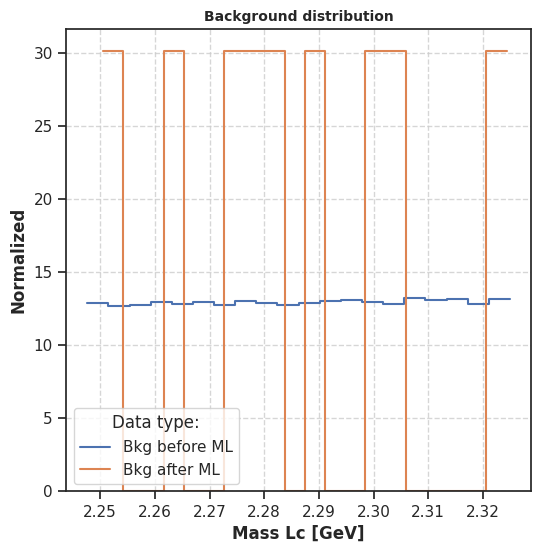

In [32]:
from scipy import stats


threshold = optimal_threshold
alpha = 0.05

df = x_test_full[['mass_Lc']].copy()
df['y_true'] = y_test
df['y_pred_proba'] = y_pred_proba_test

bkg_before_ML = df.loc[df.y_true == 0, 'mass_Lc']
bkg_after_Ml = df.loc[(df.y_pred_proba >= threshold) & (df.y_true == 0), 'mass_Lc']

# kolmogorov-Smirnov test
ks_stat, p_value = stats.ks_2samp(bkg_before_ML, bkg_after_Ml, alternative='two-sided')

try:
    experiment.log_metric(name='KS-test p-value', value=p_value)
except NameError:
    pass

if p_value >= alpha:
    print(f'KS-test: distributions are identical, ({alpha=}, {p_value=:0.3f})')
else:
    print(f'KS-test: distributions are different, ({alpha=}, {p_value=:0.3f})')


fig, ax = plt.subplots(figsize=(6, 6))

sns.histplot(
    data=bkg_before_ML,
    label='Bkg before ML',
    element='step',
    fill=False,
    stat='density',
    bins=20,
    # alpha=0.8,
    ax=ax
)

sns.histplot(
    data=bkg_after_Ml,
    label='Bkg after ML',
    element='step',
    fill=False,
    stat='density',
    bins=20,
    # alpha=0.8,
    ax=ax
)

plt.legend(title="Data type:", loc= "best")

ax.set_title('Background distribution', fontsize=10, fontweight='bold')
ax.set_xlabel('Mass Lc [GeV]', fontweight='bold')
ax.set_ylabel('Normalized', fontweight='bold')
ax.grid(True, alpha=0.8, linestyle='--')

try:
    experiment.log_figure(
        figure_name=f"Bkg distr ML",
        figure=plt.gcf()
    )
except NameError:
    pass

fig.savefig('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/bkg_shape.pdf', bbox_inches='tight')
plt.show()

# Cut-based ending

## Get ML-handled data

In [14]:
y_pred_val = np.where(y_pred_proba_val >= optimal_threshold, 1, 0) 

df = x_val_full.copy()
df['tag'] = y_val.map({1: 'Sig', 0: 'Bg'})
df['pred_tag'] = y_pred_val.copy()

init_bkg_distr = df.loc[df['tag'] == 'Bg', 'mass_Lc'].copy()

df = df[df['pred_tag'] == 1]

## Selection Path Setup

In [15]:
result_df = create_best_selection_path(
    df=df,
    features=CFG.feature_cut_based_sel,
    n_features_to_use=None,
    metric_type='tpr_fpr',
    have_sig_events=1,
    have_bg_events=1,
    mass_interval=CFG.mass_interval,
    direction_restrictions=CFG.cut_based_sel_restriction,
    nbins=1000,
)

Selection Progress: 1/87
Remaining features: 87
Remaining events - Signal: 9061, Background: 303
****************************************
Progress: 1/87
Process feature: Pt_p
Direction restriction encounter. Skip direction: left
Cut point search progress: 0/1000
Cut point search progress: 200/1000
Cut point search progress: 400/1000
Cut point search progress: 600/1000
Cut point search progress: 800/1000
AUC value: 0.6060, direction: right
****************************************
Progress: 2/87
Process feature: Pt_K
Direction restriction encounter. Skip direction: left
Cut point search progress: 0/1000
Cut point search progress: 200/1000
Cut point search progress: 400/1000
Cut point search progress: 600/1000
Cut point search progress: 800/1000
AUC value: 0.5119, direction: right
****************************************
Progress: 3/87
Process feature: Pt_pip
Direction restriction encounter. Skip direction: left
Cut point search progress: 0/1000
Cut point search progress: 200/1000
Cut poi

In [16]:
result_df

,selected_feature,cut_point,select_direction,signal_efficiency,background_efficiency,ratio,overall_s_sqrt_s_b,total_sig_unscaled,total_bg_unscaled
0,sum_pt_abs,2.623672,right,0.574330,0.359736,0.000176,20101.357516,5204,109
1,l_over_dl_XY,0.694676,right,0.430822,0.229358,0.000330,18081.456511,2242,25
2,dist_K_Lc_xy_custom,0.004649,left,0.715433,0.400000,0.000591,20451.050451,1604,10
3,Pt_p,1.236997,right,0.569825,0.100000,0.003367,36800.672084,914,1


## Selection Var 1

In [17]:
cut_based_sig_efficiency = 1
cut_based_bg_suppression = 1

cut_based_selection_mask_train = np.ones(df.shape[0], dtype=bool)
cut_based_selection_mask_test = np.ones(test_df.shape[0], dtype=bool)

cut_based_selection_mask_test *=  np.where(y_pred_proba_test >= optimal_threshold, True, False) 

df_copy = df.copy()

### Cut 1: sum_pt_abs

Cut point search progress: 0/1000
Cut point search progress: 200/1000
Cut point search progress: 400/1000
Cut point search progress: 600/1000
Cut point search progress: 800/1000
Cut point: 2.6236724748804763
Signal efficiency: 0.5743295442004194
Background Suppression: 0.35973597359735976


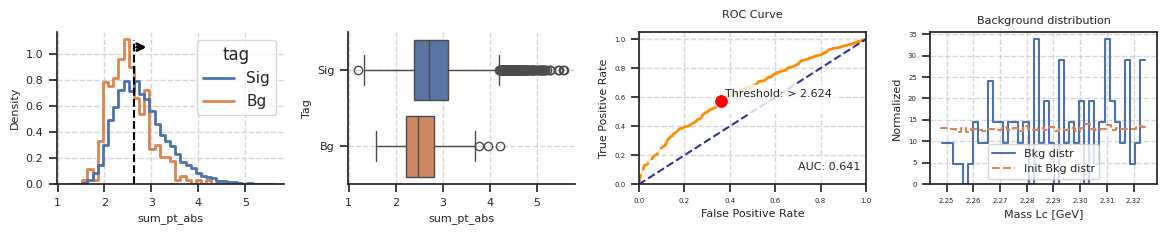

In [18]:
feature = 'sum_pt_abs'
select_direction = 'right'
metric_type = 'tpr_fpr'
bounds = None
min_sig_sel = 0.3

num_sig_before_sel = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count()
num_bg_before_sel = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count()

min_sig_sel_mask, best_arg, metric, thresholds, tpr, fpr, sig_efficiency, bg_efficiency = find_optimal_cut_point(
    df=df[['mass_Lc', 'tag', feature]],
    feature=feature,
    bounds=bounds,
    nbins=1000,
    select_direction=select_direction,
    metric_type=metric_type,
    min_sig_sel=min_sig_sel,
    mass_interval=CFG.mass_interval
)

if bounds is not None:
    bounds_mask = (df[feature] >= bounds[0]) & (df[feature] <= bounds[1])
    df = df[bounds_mask]
    
best_cut_x = thresholds[min_sig_sel_mask][best_arg]
best_metric = metric[min_sig_sel_mask][best_arg]
best_tpr = tpr[min_sig_sel_mask][best_arg]
best_fpr = fpr[min_sig_sel_mask][best_arg]

#--------------------------------------------------
# # Manual cut
# best_cut_x = 1.1758495257275554
# 
# # find index by value
# val = best_cut_x
# arr = thresholds[min_sig_sel_mask]
# 
# diff = abs(arr - val)
# index = np.argmin(diff)
#     
# best_tpr = tpr[min_sig_sel_mask][index]
# best_fpr = fpr[min_sig_sel_mask][index]
#--------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5))
draw_feature_distribution(
    df=df,
    distr_name=feature,
    tag=None,
    axes=[axes[0], axes[1]],
    hue='tag',
    bins=40,
    norma=True,
    cut_point=best_cut_x,
    select_direction=select_direction
)

_ = draw_roc(
        tpr=tpr,
        fpr=fpr,
        ax=axes[2],
        best_cut_x=best_cut_x,
        best_tpr=best_tpr,
        best_fpr=best_fpr,
        select_direction=select_direction,
        mask=min_sig_sel_mask,
        min_sig_sel=min_sig_sel
    )

# Mask 
if select_direction == 'right':
    mask = df[feature] > best_cut_x
    general_mask_train = df_copy[feature] > best_cut_x
    general_mask_test = test_df[feature] > best_cut_x
else:
    mask = df[feature] < best_cut_x
    general_mask_train = df_copy[feature] < best_cut_x
    general_mask_test = test_df[feature] < best_cut_x

df = df[mask]
cut_based_selection_mask_train &= general_mask_train
cut_based_selection_mask_test &= general_mask_test

print(f'Cut point: {best_cut_x}')

sig_eff = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count() / num_sig_before_sel
bg_eff = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count() / num_bg_before_sel

total_sig_efficiency *= sig_eff
total_bg_suppression *= bg_eff

print(f'Signal efficiency: {sig_eff}')
print(f'Background Suppression: {bg_eff}')

sns.histplot(
    data=df.loc[df['tag'] == 'Bg', 'mass_Lc'],
    label='Bkg distr',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

sns.histplot(
    data=init_bkg_distr,
    label='Init Bkg distr',
    linestyle='--',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

plt.legend(loc= "best", fontsize=8)

axes[3].set_title('Background distribution', fontsize=8)
axes[3].set_xlabel('Mass Lc [GeV]', fontsize=8)
axes[3].set_ylabel('Normalized', fontsize=8)
axes[3].tick_params(axis='both', which='major', labelsize=5)
axes[3].grid(True, alpha=0.8, linestyle='--')

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{feature}_cut_after_ML.pdf', bbox_inches='tight')

### Cut 2: l_over_dl_XY

Cut point search progress: 0/1000
Cut point search progress: 200/1000
Cut point search progress: 400/1000
Cut point search progress: 600/1000
Cut point search progress: 800/1000
Cut point: 0.6946757991351955
Signal efficiency: 0.43082244427363564
Background Suppression: 0.22935779816513763


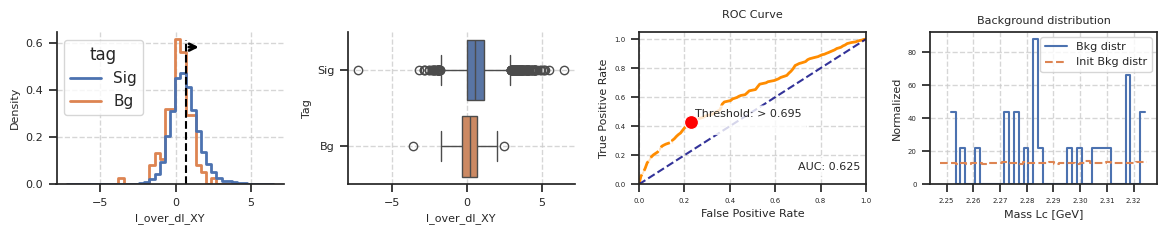

In [19]:
feature = 'l_over_dl_XY'
select_direction = 'right'
metric_type = 'tpr_fpr'
bounds = None
min_sig_sel = 0.3

num_sig_before_sel = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count()
num_bg_before_sel = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count()

min_sig_sel_mask, best_arg, metric, thresholds, tpr, fpr, sig_efficiency, bg_efficiency = find_optimal_cut_point(
    df=df[['mass_Lc', 'tag', feature]],
    feature=feature,
    bounds=bounds,
    nbins=1000,
    select_direction=select_direction,
    metric_type=metric_type,
    min_sig_sel=min_sig_sel,
    mass_interval=CFG.mass_interval
)

if bounds is not None:
    bounds_mask = (df[feature] >= bounds[0]) & (df[feature] <= bounds[1])
    df = df[bounds_mask]
    
best_cut_x = thresholds[min_sig_sel_mask][best_arg]
best_metric = metric[min_sig_sel_mask][best_arg]
best_tpr = tpr[min_sig_sel_mask][best_arg]
best_fpr = fpr[min_sig_sel_mask][best_arg]

#--------------------------------------------------
# # Manual cut
# best_cut_x = 1.863236683863658
# 
# # find index by value
# val = best_cut_x
# arr = thresholds[min_sig_sel_mask]
# 
# diff = abs(arr - val)
# index = np.argmin(diff)
#     
# best_tpr = tpr[min_sig_sel_mask][index]
# best_fpr = fpr[min_sig_sel_mask][index]
#--------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5))
draw_feature_distribution(
    df=df,
    distr_name=feature,
    tag=None,
    axes=[axes[0], axes[1]],
    hue='tag',
    bins=40,
    norma=True,
    cut_point=best_cut_x,
    select_direction=select_direction
)

_ = draw_roc(
        tpr=tpr,
        fpr=fpr,
        ax=axes[2],
        best_cut_x=best_cut_x,
        best_tpr=best_tpr,
        best_fpr=best_fpr,
        select_direction=select_direction,
        mask=min_sig_sel_mask,
        min_sig_sel=min_sig_sel
    )

# Mask 
if select_direction == 'right':
    mask = df[feature] > best_cut_x
    general_mask_train = df_copy[feature] > best_cut_x
    general_mask_test = test_df[feature] > best_cut_x
else:
    mask = df[feature] < best_cut_x
    general_mask_train = df_copy[feature] < best_cut_x
    general_mask_test = test_df[feature] < best_cut_x

df = df[mask]
cut_based_selection_mask_train &= general_mask_train
cut_based_selection_mask_test &= general_mask_test

print(f'Cut point: {best_cut_x}')

sig_eff = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count() / num_sig_before_sel
bg_eff = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count() / num_bg_before_sel

total_sig_efficiency *= sig_eff
total_bg_suppression *= bg_eff

print(f'Signal efficiency: {sig_eff}')
print(f'Background Suppression: {bg_eff}')

sns.histplot(
    data=df.loc[df['tag'] == 'Bg', 'mass_Lc'],
    label='Bkg distr',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

sns.histplot(
    data=init_bkg_distr,
    label='Init Bkg distr',
    linestyle='--',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

plt.legend(loc= "best", fontsize=8)

axes[3].set_title('Background distribution', fontsize=8)
axes[3].set_xlabel('Mass Lc [GeV]', fontsize=8)
axes[3].set_ylabel('Normalized', fontsize=8)
axes[3].tick_params(axis='both', which='major', labelsize=5)
axes[3].grid(True, alpha=0.8, linestyle='--')

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{feature}_cut_after_ML.pdf', bbox_inches='tight')

### Cut 3: dist_K_Lc_xy_custom

Cut point search progress: 0/1000
Cut point search progress: 200/1000
Cut point search progress: 400/1000
Cut point search progress: 600/1000
Cut point search progress: 800/1000
Cut point: 0.004648841161527361
Signal efficiency: 0.7154326494201606
Background Suppression: 0.4


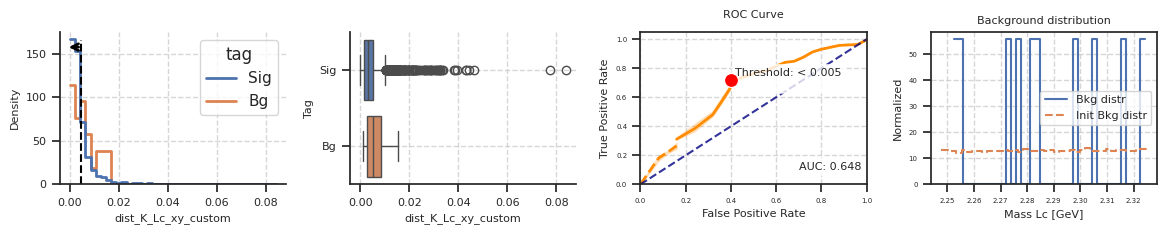

In [20]:
feature = 'dist_K_Lc_xy_custom'
select_direction = 'left'
metric_type = 'tpr_fpr'
bounds = None
min_sig_sel = 0.3

num_sig_before_sel = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count()
num_bg_before_sel = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count()

min_sig_sel_mask, best_arg, metric, thresholds, tpr, fpr, sig_efficiency, bg_efficiency = find_optimal_cut_point(
    df=df[['mass_Lc', 'tag', feature]],
    feature=feature,
    bounds=bounds,
    nbins=1000,
    select_direction=select_direction,
    metric_type=metric_type,
    min_sig_sel=min_sig_sel,
    mass_interval=CFG.mass_interval
)

if bounds is not None:
    bounds_mask = (df[feature] >= bounds[0]) & (df[feature] <= bounds[1])
    df = df[bounds_mask]
    
best_cut_x = thresholds[min_sig_sel_mask][best_arg]
best_metric = metric[min_sig_sel_mask][best_arg]
best_tpr = tpr[min_sig_sel_mask][best_arg]
best_fpr = fpr[min_sig_sel_mask][best_arg]

#--------------------------------------------------
# # Manual cut
# best_cut_x = 4.043374628601767
# 
# # find index by value
# val = best_cut_x
# arr = thresholds[min_sig_sel_mask]
# 
# diff = abs(arr - val)
# index = np.argmin(diff)
#     
# best_tpr = tpr[min_sig_sel_mask][index]
# best_fpr = fpr[min_sig_sel_mask][index]
#--------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5))
draw_feature_distribution(
    df=df,
    distr_name=feature,
    tag=None,
    axes=[axes[0], axes[1]],
    hue='tag',
    bins=40,
    norma=True,
    cut_point=best_cut_x,
    select_direction=select_direction
)

_ = draw_roc(
        tpr=tpr,
        fpr=fpr,
        ax=axes[2],
        best_cut_x=best_cut_x,
        best_tpr=best_tpr,
        best_fpr=best_fpr,
        select_direction=select_direction,
        mask=min_sig_sel_mask,
        min_sig_sel=min_sig_sel
    )

# Mask 
if select_direction == 'right':
    mask = df[feature] > best_cut_x
    general_mask_train = df_copy[feature] > best_cut_x
    general_mask_test = test_df[feature] > best_cut_x
else:
    mask = df[feature] < best_cut_x
    general_mask_train = df_copy[feature] < best_cut_x
    general_mask_test = test_df[feature] < best_cut_x

df = df[mask]
cut_based_selection_mask_train &= general_mask_train
cut_based_selection_mask_test &= general_mask_test

print(f'Cut point: {best_cut_x}')

sig_eff = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count() / num_sig_before_sel
bg_eff = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count() / num_bg_before_sel

total_sig_efficiency *= sig_eff
total_bg_suppression *= bg_eff

print(f'Signal efficiency: {sig_eff}')
print(f'Background Suppression: {bg_eff}')

sns.histplot(
    data=df.loc[df['tag'] == 'Bg', 'mass_Lc'],
    label='Bkg distr',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

sns.histplot(
    data=init_bkg_distr,
    label='Init Bkg distr',
    linestyle='--',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

plt.legend(loc= "best", fontsize=8)

axes[3].set_title('Background distribution', fontsize=8)
axes[3].set_xlabel('Mass Lc [GeV]', fontsize=8)
axes[3].set_ylabel('Normalized', fontsize=8)
axes[3].tick_params(axis='both', which='major', labelsize=5)
axes[3].grid(True, alpha=0.8, linestyle='--')

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{feature}_cut_after_ML.pdf', bbox_inches='tight')

### Cut 4: Pt_p

Cut point search progress: 0/1000
Cut point search progress: 200/1000
Cut point search progress: 400/1000
Cut point search progress: 600/1000
Cut point search progress: 800/1000
Cut point: 1.2369965496542932
Signal efficiency: 0.5698254364089775
Background Suppression: 0.1


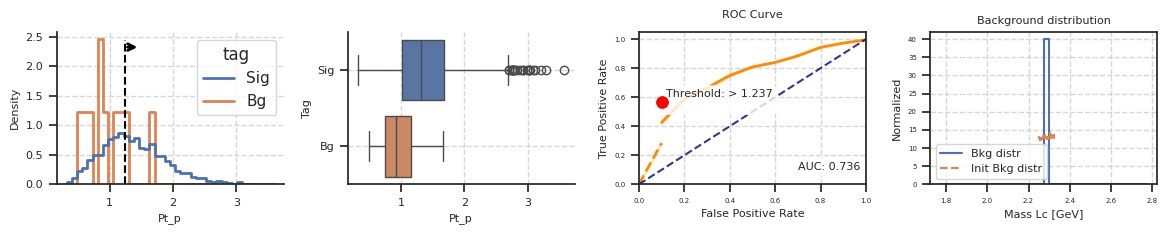

In [21]:
feature = 'Pt_p'
select_direction = 'right'
metric_type = 'tpr_fpr'
bounds = None
min_sig_sel = 0.3

num_sig_before_sel = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count()
num_bg_before_sel = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count()

min_sig_sel_mask, best_arg, metric, thresholds, tpr, fpr, sig_efficiency, bg_efficiency = find_optimal_cut_point(
    df=df[['mass_Lc', 'tag', feature]],
    feature=feature,
    bounds=bounds,
    nbins=1000,
    select_direction=select_direction,
    metric_type=metric_type,
    min_sig_sel=min_sig_sel,
    mass_interval=CFG.mass_interval
)

if bounds is not None:
    bounds_mask = (df[feature] >= bounds[0]) & (df[feature] <= bounds[1])
    df = df[bounds_mask]
    
best_cut_x = thresholds[min_sig_sel_mask][best_arg]
best_metric = metric[min_sig_sel_mask][best_arg]
best_tpr = tpr[min_sig_sel_mask][best_arg]
best_fpr = fpr[min_sig_sel_mask][best_arg]

#--------------------------------------------------
# # Manual cut
# best_cut_x = 1.1758495257275554
# 
# # find index by value
# val = best_cut_x
# arr = thresholds[min_sig_sel_mask]
# 
# diff = abs(arr - val)
# index = np.argmin(diff)
#     
# best_tpr = tpr[min_sig_sel_mask][index]
# best_fpr = fpr[min_sig_sel_mask][index]
#--------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(12, 2.5))
draw_feature_distribution(
    df=df,
    distr_name=feature,
    tag=None,
    axes=[axes[0], axes[1]],
    hue='tag',
    bins=40,
    norma=True,
    cut_point=best_cut_x,
    select_direction=select_direction
)

_ = draw_roc(
        tpr=tpr,
        fpr=fpr,
        ax=axes[2],
        best_cut_x=best_cut_x,
        best_tpr=best_tpr,
        best_fpr=best_fpr,
        select_direction=select_direction,
        mask=min_sig_sel_mask,
        min_sig_sel=min_sig_sel
    )

# Mask 
if select_direction == 'right':
    mask = df[feature] > best_cut_x
    general_mask_train = df_copy[feature] > best_cut_x
    general_mask_test = test_df[feature] > best_cut_x
else:
    mask = df[feature] < best_cut_x
    general_mask_train = df_copy[feature] < best_cut_x
    general_mask_test = test_df[feature] < best_cut_x

df = df[mask]
cut_based_selection_mask_train &= general_mask_train
cut_based_selection_mask_test &= general_mask_test

print(f'Cut point: {best_cut_x}')

sig_eff = df.loc[df['tag'] == 'Sig', 'mass_Lc'].count() / num_sig_before_sel
bg_eff = df.loc[df['tag'] == 'Bg', 'mass_Lc'].count() / num_bg_before_sel

total_sig_efficiency *= sig_eff
total_bg_suppression *= bg_eff

print(f'Signal efficiency: {sig_eff}')
print(f'Background Suppression: {bg_eff}')

sns.histplot(
    data=df.loc[df['tag'] == 'Bg', 'mass_Lc'],
    label='Bkg distr',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

sns.histplot(
    data=init_bkg_distr,
    label='Init Bkg distr',
    linestyle='--',
    element='step',
    fill=False,
    stat='density',
    bins=40,
    ax=axes[3],
)

plt.legend(loc= "best", fontsize=8)

axes[3].set_title('Background distribution', fontsize=8)
axes[3].set_xlabel('Mass Lc [GeV]', fontsize=8)
axes[3].set_ylabel('Normalized', fontsize=8)
axes[3].tick_params(axis='both', which='major', labelsize=5)
axes[3].grid(True, alpha=0.8, linestyle='--')

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/{feature}_cut_after_ML.pdf', bbox_inches='tight')

# Data Stats After Selection

In [22]:
sig_before_sel = test_df.loc[test_df['tag'] == 'Sig', 'tag'].count()
bg_before_sel = test_df.loc[test_df['tag'] == 'Bg', 'tag'].count()
sig_after_sel = test_df.loc[cut_based_selection_mask_test & (test_df['tag'] == 'Sig'), 'tag'].count()
bg_after_sel = test_df.loc[cut_based_selection_mask_test & (test_df['tag'] == 'Bg'), 'tag'].count()

sig_efficiency = sig_after_sel / sig_before_sel
bg_efficiency = bg_after_sel / bg_before_sel

print(f'Signal efficiency: {sig_efficiency}')
print(f'Background suppression: {bg_efficiency}')

# From data_explore notebook
sig_eff_presel = CFG.sig_eff_presel
bg_eff_presel = CFG.bg_eff_presel


total_signal_efficiency = sig_eff_presel * sig_efficiency
total_background_efficiency = bg_eff_presel * bg_efficiency

print(f'\nTotal signal efficiency (include presel): {total_signal_efficiency}')
print(f'Total background suppression (include presel): {total_background_efficiency}')

Signal efficiency: 0.04505750924071283
Background suppression: 9.279626065438548e-05

Total signal efficiency (include presel): 0.04267761967629945
Total background suppression (include presel): 5.7537399309551206e-05



SUMMARY STATISTICS
Total Signal Events: 890832
Total Background Events: 81830895
Total Signal Events Unscaled: 96854
Total Background Events Unscaled: 290960
Overall S/B Ratio: 0.010886
Overall S/sqrt(S+B) Significance: 97.95


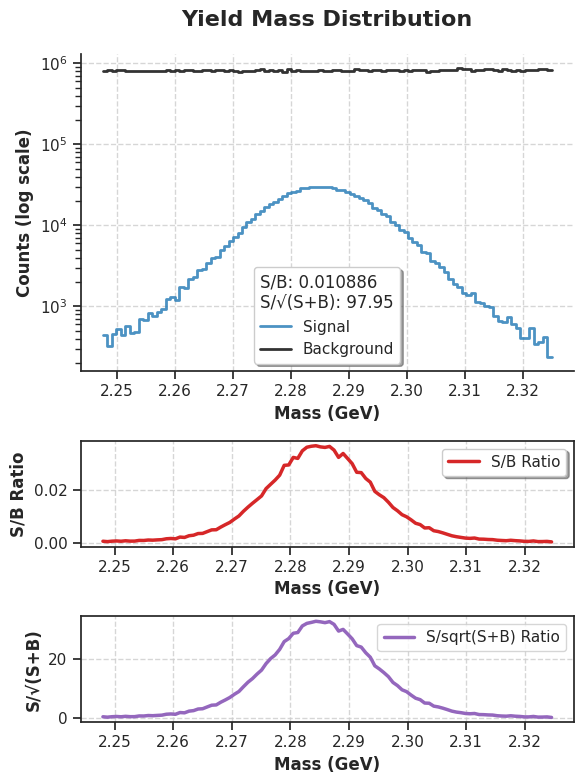

In [23]:
# Preselection stage data
sig_mass_distr = test_df.loc[test_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = test_df.loc[test_df['tag'] == 'Bg', 'mass_Lc']

_ = signal_estimates(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_efficiency, # no need to divide by sig_eff_presel for preselection stage data!!
    have_bg_events=CFG.have_bg_events_1 / bg_efficiency,
    mass_interval=CFG.mass_interval, 
    visualization=True,
    verbose=True,
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/mass_stats_after_selection_ML.pdf')

# End experiment log

In [28]:
try:
    experiment.end()
except NameError:
    pass

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Feature set 9, params_xgboost_1
COMET INFO:     url                   : https://www.comet.com/artem-smirnov/spd-ml/0693236162e74333af60f28fd99668c9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     KS-test p-value          : 0.2063428319742281
COMET INFO:     accuracy_score_test      : 0.8630973158266878
COMET INFO:     accuracy_score_train     : 0.9340795004693303
COMET INFO:     accuracy_score_val       : 0.8816927848514529
COMET INFO:     background_eff_ML        : 0.1643822455645936
COMET INFO:     cv_train_mean_roc_auc    : 0.9860572800640174
COMET INFO:     cv_val_mean_roc_auc      : 0.9559364930000586
COMET INFO:     roc_auc_score_test